'最新数据日期：2025-08-04'

,ts_code,open,high,low,close,change,volume,diff,dea,macd,...,resistance,range_start,range_end,start_type,end_type,wave_number,move_type,subwaves,target,future_5d_return
trade_date,,,,,,,,,,,,,,,,,,,,,
2025-07-29,000001.SZ,12.46,12.51,12.34,12.34,-0.12,1012818.01,-0.081048,-0.018442,-0.125212,...,NaN,NaN,NaN,bearish_zone,bearish_pivot_pivot,2.0,impulse,1.0,14.135,NaN
2025-07-30,000001.SZ,12.35,12.64,12.34,12.49,0.15,1715163.60,-0.055704,-0.026723,-0.057963,...,NaN,NaN,NaN,bearish_pivot_pivot,bullish_pivot_pivot,0.0,correction,1.0,14.135,NaN
2025-07-31,000001.SZ,12.51,12.55,12.22,12.23,-0.26,1690081.25,-0.088093,-0.040360,-0.095465,...,NaN,NaN,NaN,bearish_pivot_pivot,bearish_pivot_pivot,0.0,correction,1.0,14.135,NaN
2025-08-01,000001.SZ,12.24,12.33,12.15,12.28,0.05,1012186.98,-0.092882,-0.052032,-0.081700,...,NaN,NaN,NaN,bearish_pivot_pivot,bearish_zone,0.0,correction,1.0,14.135,NaN
2025-08-04,000001.SZ,12.24,12.38,12.21,12.30,0.02,1032689.69,-0.087386,-0.059888,-0.054996,...,NaN,NaN,NaN,bearish_pivot_pivot,bearish_zone,0.0,correction,1.0,14.135,NaN


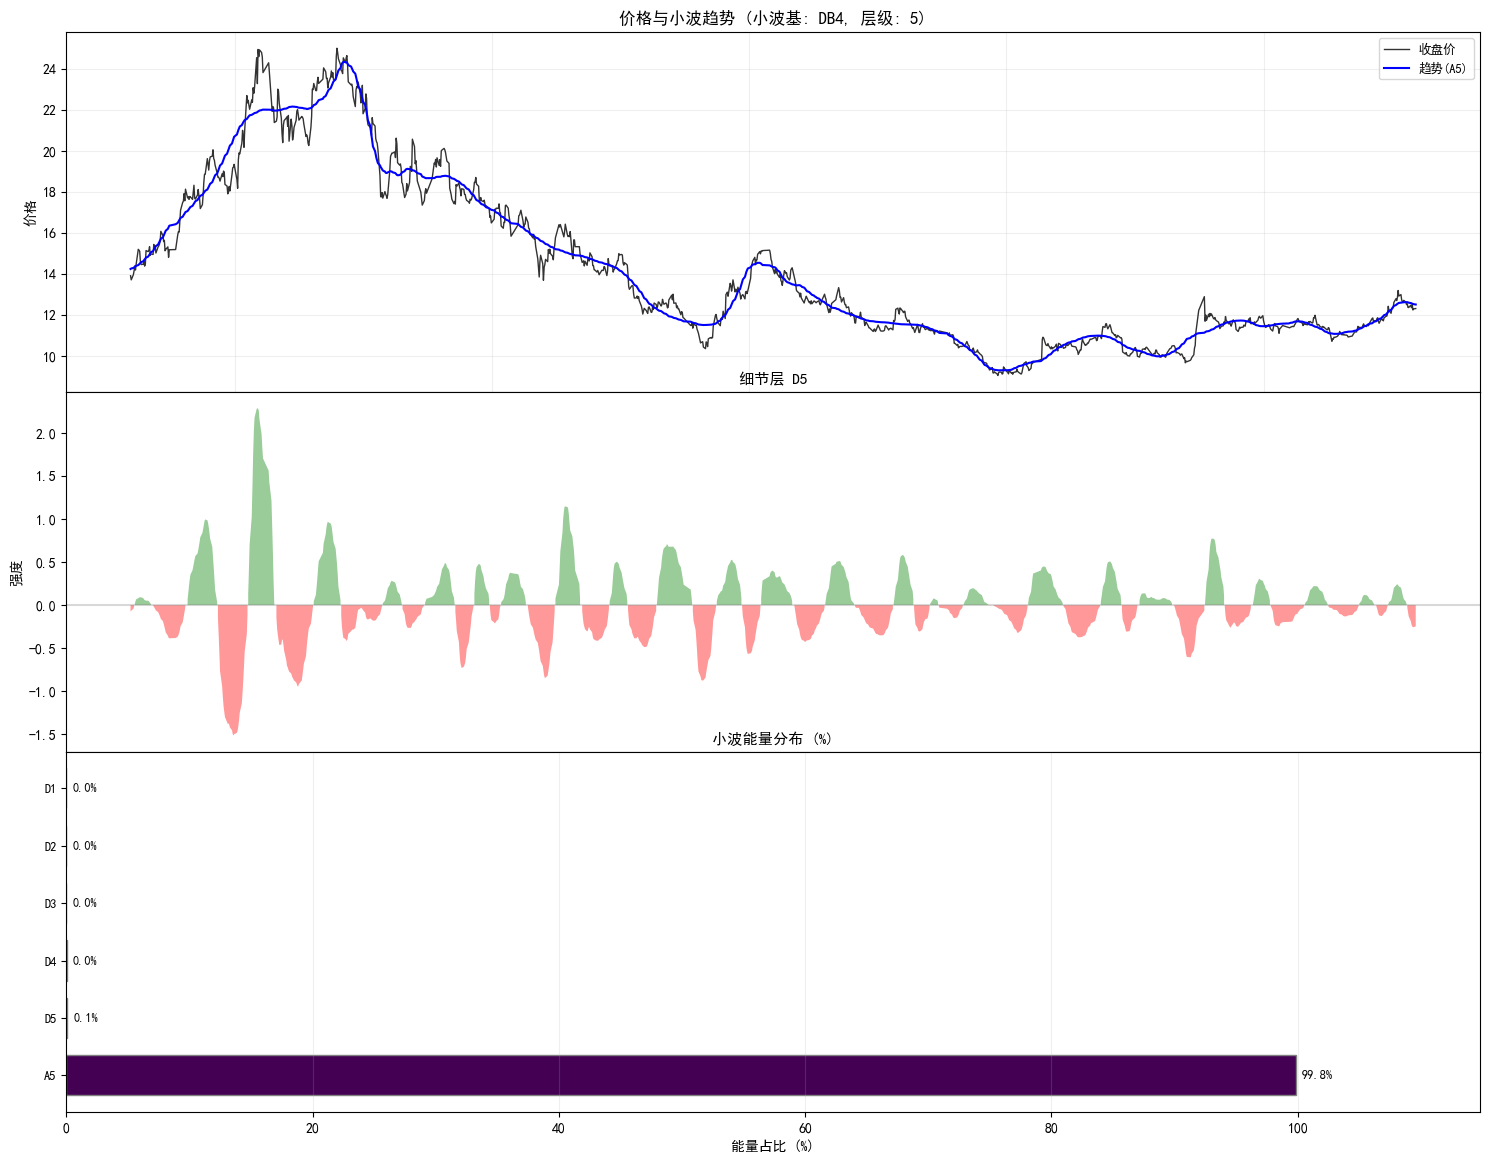

In [5]:
# 完整技术分析看盘程序 v1.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from scipy import signal
import argparse
import datetime
from numpy.lib.stride_tricks import sliding_window_view
import pywt
from matplotlib.gridspec import GridSpec


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import matplotlib.dates as mdates
import matplotlib

def wavelet_analysis(data, wavelet='db4', level=5):
    """小波分解并重建各层信号 - 高效实现"""
    coeffs = pywt.wavedec(data, wavelet, level=level)
    reconstructed = []
    for i in range(len(coeffs)):
        coeff_list = [np.zeros_like(c) for c in coeffs]
        coeff_list[i] = coeffs[i].copy()
        recon = pywt.waverec(coeff_list, wavelet)
        reconstructed.append(recon[:len(data)])
    return reconstructed

def plot_wavelet_decomposition(ohlc_df, wavelet='db4', level=5):
    """
    紧凑高效的小波分解可视化
    - 固定图像尺寸 (15x12英寸)
    - 零间距布局
    - 垂直排列所有图表
    """
    matplotlib.rcParams['font.sans-serif'] = ['SimHei'] # 设置默认字体为黑体
    matplotlib.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题
    # 确保索引是datetime类型
    if not isinstance(ohlc_df.index, pd.DatetimeIndex):
        ohlc_df = ohlc_df.copy()
        ohlc_df.index = pd.to_datetime(ohlc_df.index)
    
    # 使用小写列名
    prices = ohlc_df['close'].values
    dates = ohlc_df.index
    
    # 执行小波分解
    recon_signals = wavelet_analysis(prices, wavelet, level)
    
    # 创建紧凑布局
    plt.figure(figsize=(15, 12))
    
    # 创建垂直网格 (无间距)
    n_plots = 3  # 价格+D5细节层+能量分布
    gs = plt.GridSpec(n_plots, 1, hspace=0)
    
    # ================== 1. 价格与趋势 ==================
    ax0 = plt.subplot(gs[0])
    plt.title(f'价格与小波趋势 (小波基: {wavelet.upper()}, 层级: {level})', fontsize=12)
    
    # 简化价格展示
    plt.plot(dates, prices, 'k-', linewidth=1.0, alpha=0.8, label='收盘价')
    plt.plot(dates, recon_signals[0], 'b-', linewidth=1.5, label=f'趋势(A{level})')
    
    # 设置日期格式 - 但隐藏标签（由底部图显示）
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax0.get_xticklabels(), visible=False)  # 隐藏x轴标签
    
    plt.legend(loc='best', fontsize=9)
    plt.grid(alpha=0.2)
    plt.ylabel('价格', fontsize=10)

    # ================== 2. 只显示D5细节层 ==================
    ax1 = plt.subplot(gs[1])
    
    # 获取D5细节层 (索引为1)
    d5_signal = recon_signals[1]
    
    # 简化细节信号展示
    plt.fill_between(dates, d5_signal, 0, 
                    where=(d5_signal >= 0), 
                    facecolor='green', alpha=0.4)
    plt.fill_between(dates, d5_signal, 0, 
                    where=(d5_signal < 0), 
                    facecolor='red', alpha=0.4)
    plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
    
    plt.title(f'细节层 D5', fontsize=11)
    plt.ylabel('强度', fontsize=10)
    
    # 设置日期格式 - 但隐藏标签（由底部图显示）
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax1.get_xticklabels(), visible=False)  # 隐藏x轴标签
    
    # ================== 3. 能量分布 ==================
    ax2 = plt.subplot(gs[2])
    
    # 计算能量分布
    energies = [np.sum(np.square(sig)) for sig in recon_signals]
    total_energy = sum(energies)
    energy_percent = [e/total_energy*100 for e in energies]
    
    # 创建标签
    labels = [f'A{level}'] 
    for i in range(level):
        labels.append(f'D{level-i}')
    
    # 紧凑条形图
    y_pos = np.arange(len(labels))
    colors = plt.cm.viridis(np.linspace(0, 1, level+1))
    
    plt.barh(y_pos, energy_percent, color=colors, edgecolor='gray', height=0.7)
    
    # 添加数值标签
    for i, v in enumerate(energy_percent):
        plt.text(v + 0.5, i, f'{v:.1f}%', fontsize=9, va='center')
    
    plt.yticks(y_pos, labels, fontsize=9)
    plt.title('小波能量分布 (%)', fontsize=11)
    plt.grid(axis='x', alpha=0.2)
    plt.xlim(0, max(energy_percent)*1.15)
    
    # 在能量分布图上添加日期标签（作为底部图的x轴）
    plt.xlabel('能量占比 (%)', fontsize=10)  # 能量图不需要日期，所以改为百分比标签
    
    # 紧凑布局
    plt.tight_layout()
    plt.subplots_adjust(top=0.97, bottom=0.07, hspace=0.05)
    
    # 在D5细节图上显示日期标签（作为底部时间序列图）
    plt.figure(plt.gcf().number)  # 确保我们操作的是当前图形
    plt.sca(ax1)  # 切换到D5细节图
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.xlabel('日期', fontsize=10)
    
    # 保存和显示
    plt.savefig('compact_wavelet.png', dpi=150, bbox_inches='tight')
    plt.show()





    
import os
from pathlib import Path
# ================= 主程序 =================
if __name__ == "__main__":
    ts_code =  "000001.SZ"
    analysis_dir = os.path.join('E:\stock\csv_version','analysis_results')
    csv_path = Path(analysis_dir) / f"{ts_code}_analysis.csv"    
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'])
    
   
    # 检查数据样例
    display(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    display(df.tail())
    
    # 假设数据已加载为df，直接调用函数
    plot_wavelet_decomposition(df)
